# Tourism Package Prediction — MLOps Pipeline


# Problem Statement

## **Business Context**

"Visit with Us," a leading travel company, is revolutionizing the tourism industry by leveraging data-driven strategies to optimize operations and customer engagement. While introducing a new package offering, such as the Wellness Tourism Package, the company faces challenges in targeting the right customers efficiently. The manual approach to identifying potential customers is inconsistent, time-consuming, and prone to errors, leading to missed opportunities and suboptimal campaign performance.

To address these issues, the company aims to implement a scalable and automated system that integrates customer data, predicts potential buyers, and enhances decision-making for marketing strategies. By utilizing an MLOps pipeline, the company seeks to achieve seamless integration of data preprocessing, model development, deployment, and CI/CD practices for continuous improvement. This system will ensure efficient targeting of customers, timely updates to the predictive model, and adaptation to evolving customer behaviors, ultimately driving growth and customer satisfaction.


## **Objective**

As an MLOps Engineer at "Visit with Us," your responsibility is to design and deploy an MLOps pipeline on GitHub to automate the end-to-end workflow for predicting customer purchases. The primary objective is to build a model that predicts whether a customer will purchase the newly introduced Wellness Tourism Package before contacting them. The pipeline will include data cleaning, preprocessing, transformation, model building, training, evaluation, and deployment, ensuring consistent performance and scalability. By leveraging GitHub Actions for CI/CD integration, the system will enable automated updates, streamline model deployment, and improve operational efficiency. This robust predictive solution will empower policymakers to make data-driven decisions, enhance marketing strategies, and effectively target potential customers, thereby driving customer acquisition and business growth.

## **Data Description**

The dataset contains customer and interaction data that serve as key attributes for predicting the likelihood of purchasing the Wellness Tourism Package. The detailed attributes are:

**Customer Details**
- **CustomerID:** Unique identifier for each customer.
- **ProdTaken:** Target variable indicating whether the customer has purchased a package (0: No, 1: Yes).
- **Age:** Age of the customer.
- **TypeofContact:** The method by which the customer was contacted (Company Invited or Self Inquiry).
- **CityTier:** The city category based on development, population, and living standards (Tier 1 > Tier 2 > Tier 3).
- **Occupation:** Customer's occupation (e.g., Salaried, Freelancer).
- **Gender:** Gender of the customer (Male, Female).
- **NumberOfPersonVisiting:** Total number of people accompanying the customer on the trip.
- **PreferredPropertyStar:** Preferred hotel rating by the customer.
- **MaritalStatus:** Marital status of the customer (Single, Married, Divorced).
- **NumberOfTrips:** Average number of trips the customer takes annually.
- **Passport:** Whether the customer holds a valid passport (0: No, 1: Yes).
- **OwnCar:** Whether the customer owns a car (0: No, 1: Yes).
- **NumberOfChildrenVisiting:** Number of children below age 5 accompanying the customer.
- **Designation:** Customer's designation in their current organization.
- **MonthlyIncome:** Gross monthly income of the customer.

**Customer Interaction Data**
- **PitchSatisfactionScore:** Score indicating the customer's satisfaction with the sales pitch.
- **ProductPitched:** The type of product pitched to the customer.
- **NumberOfFollowups:** Total number of follow-ups by the salesperson after the sales pitch.-
- **DurationOfPitch:** Duration of the sales pitch delivered to the customer.


## Development & Deployment Approach

This notebook was developed and executed locally in Jupyter (Python 3.11, a dedicated conda environment). Instead of the Colab + PyGithub + Personal Access Token flow, version control is handled with **git** and the **GitHub CLI (`gh`)**, which were already authenticated on this machine. This keeps no tokens or secrets embedded in the notebook itself.

The end-to-end flow demonstrated below is:
1. Build the `tourism_project/` folder structure and register/clean the data.
2. Split the data and train/tune an XGBoost model with MLflow experiment tracking.
3. Save the best model and build a Streamlit inference app.
4. Define a GitHub Actions workflow (`.github/workflows/pipeline.yml`) that automates steps 1–3 on every push to `main`, and commits the retrained model back to the repository.
5. Push everything to GitHub and deploy the Streamlit app on Streamlit Community Cloud.

- **GitHub repository:** https://github.com/craghav12/tourism-package-prediction
- **Streamlit app:** https://tourism-package-prediction-craghav12.streamlit.app/


## Installing and Importing Necessary Libraries

In [1]:
%pip install -q -r requirements.txt


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import subprocess

import joblib
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import pandas as pd
import xgboost as xgb
from sklearn.compose import make_column_transformer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# Model Building

In [3]:
# Create a master folder to keep all files created when executing the below code cells
os.makedirs("tourism_project", exist_ok=True)


In [4]:
# Create a folder for storing the model building files
os.makedirs("tourism_project/model_building", exist_ok=True)


## Data Registration

In [5]:
os.makedirs("tourism_project/data", exist_ok=True)


The raw `tourism.csv` file is already committed at `tourism_project/data/tourism.csv`. The cell below copies it there if it is ever missing (e.g. on a fresh checkout where only the top-level CSV exists).

In [6]:
import shutil

dest = "tourism_project/data/tourism.csv"
if not os.path.exists(dest) and os.path.exists("tourism.csv"):
    shutil.copy("tourism.csv", dest)
print("Dataset present:", os.path.exists(dest))


Dataset present: True


`tourism_project/model_building/data_register.py` reads this CSV from the repo, checks that all expected columns are present, and prints a summary (shape, dtypes, missing values, target distribution).

In [7]:
%%writefile tourism_project/model_building/data_register.py
"""
Registers the tourism dataset: validates that all expected columns are
present with the expected dtypes, and prints a summary of the dataset.

Run from the repository root:
    python tourism_project/model_building/data_register.py
"""

import os
import sys

import pandas as pd

DATA_PATH = os.path.join("tourism_project", "data", "tourism.csv")

EXPECTED_COLUMNS = [
    "CustomerID",
    "ProdTaken",
    "Age",
    "TypeofContact",
    "CityTier",
    "DurationOfPitch",
    "Occupation",
    "Gender",
    "NumberOfPersonVisiting",
    "NumberOfFollowups",
    "ProductPitched",
    "PreferredPropertyStar",
    "MaritalStatus",
    "NumberOfTrips",
    "Passport",
    "PitchSatisfactionScore",
    "OwnCar",
    "NumberOfChildrenVisiting",
    "Designation",
    "MonthlyIncome",
]


def register_dataset(data_path: str = DATA_PATH) -> pd.DataFrame:
    if not os.path.exists(data_path):
        raise FileNotFoundError(f"Dataset not found at '{data_path}'.")

    df = pd.read_csv(data_path)

    # Drop the stray index column that gets exported by some spreadsheet tools,
    # if present, so the column check below reflects the real schema.
    unnamed_cols = [c for c in df.columns if c.startswith("Unnamed")]
    if unnamed_cols:
        df = df.drop(columns=unnamed_cols)

    missing_columns = sorted(set(EXPECTED_COLUMNS) - set(df.columns))
    if missing_columns:
        raise ValueError(f"Dataset is missing expected columns: {missing_columns}")

    print("=" * 60)
    print("DATASET REGISTRATION SUMMARY")
    print("=" * 60)
    print(f"Source file        : {data_path}")
    print(f"Rows x Columns      : {df.shape[0]} x {df.shape[1]}")
    print(f"All expected columns present: Yes ({len(EXPECTED_COLUMNS)} columns)")
    print("-" * 60)
    print("Column dtypes:")
    print(df.dtypes)
    print("-" * 60)
    print("Missing values per column:")
    print(df.isnull().sum())
    print("-" * 60)
    print("Target distribution (ProdTaken):")
    print(df["ProdTaken"].value_counts(normalize=True).rename("proportion"))
    print("=" * 60)

    return df


if __name__ == "__main__":
    try:
        register_dataset()
    except (FileNotFoundError, ValueError) as exc:
        print(f"Dataset registration failed: {exc}", file=sys.stderr)
        sys.exit(1)


Overwriting tourism_project/model_building/data_register.py


In [8]:
!python tourism_project/model_building/data_register.py


DATASET REGISTRATION SUMMARY
Source file        : tourism_project/data/tourism.csv
Rows x Columns      : 4128 x 20
All expected columns present: Yes (20 columns)
------------------------------------------------------------
Column dtypes:
CustomerID                    int64
ProdTaken                     int64
Age                         float64
TypeofContact                object
CityTier                      int64
DurationOfPitch             float64
Occupation                   object
Gender                       object
NumberOfPersonVisiting        int64
NumberOfFollowups           float64
ProductPitched               object
PreferredPropertyStar       float64
MaritalStatus                object
NumberOfTrips               float64
Passport                      int64
PitchSatisfactionScore        int64
OwnCar                        int64
NumberOfChildrenVisiting    float64
Designation                  object
MonthlyIncome               float64
dtype: object
----------------------------

## Data Preparation

`tourism_project/model_building/prep.py` loads the dataset from the repository data folder, drops the identifier/index columns, fixes inconsistent category labels (e.g. `"Fe Male"` → `"Female"`), removes duplicate rows, and splits the data into train/test sets saved locally as CSV files. The GitHub Actions workflow passes these files to the next job as a workflow artifact.

In [9]:
%%writefile tourism_project/model_building/prep.py
"""
Loads the tourism dataset from the repository data folder, cleans it,
and splits it into train/test sets saved locally as CSV files.

Run from the repository root:
    python tourism_project/model_building/prep.py
"""

import os

import pandas as pd
from sklearn.model_selection import train_test_split

DATA_PATH = os.path.join("tourism_project", "data", "tourism.csv")
TARGET_COLUMN = "ProdTaken"
TEST_SIZE = 0.2
RANDOM_STATE = 42


def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Drop the stray pandas index column exported alongside the CSV, and
    # CustomerID, which is a unique identifier with no predictive value.
    unnamed_cols = [c for c in df.columns if c.startswith("Unnamed")]
    df = df.drop(columns=unnamed_cols + ["CustomerID"], errors="ignore")

    # Fix inconsistent category labels found in the raw data.
    df["Gender"] = df["Gender"].replace({"Fe Male": "Female"})
    df["MaritalStatus"] = df["MaritalStatus"].replace({"Unmarried": "Single"})

    # Drop exact duplicate rows and rows missing the target label, if any.
    df = df.drop_duplicates()
    df = df.dropna(subset=[TARGET_COLUMN])

    return df


def prepare_data():
    df = pd.read_csv(DATA_PATH)
    df = clean_data(df)

    X = df.drop(columns=[TARGET_COLUMN])
    y = df[TARGET_COLUMN]

    Xtrain, Xtest, ytrain, ytest = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )

    Xtrain.to_csv("Xtrain.csv", index=False)
    Xtest.to_csv("Xtest.csv", index=False)
    ytrain.to_csv("ytrain.csv", index=False)
    ytest.to_csv("ytest.csv", index=False)

    print("Data preparation complete.")
    print(f"Cleaned dataset shape : {df.shape}")
    print(f"Xtrain shape          : {Xtrain.shape}")
    print(f"Xtest shape           : {Xtest.shape}")
    print(f"Train target balance  :\n{ytrain.value_counts(normalize=True)}")
    print(f"Test target balance   :\n{ytest.value_counts(normalize=True)}")

    return Xtrain, Xtest, ytrain, ytest


if __name__ == "__main__":
    prepare_data()


Overwriting tourism_project/model_building/prep.py


In [10]:
!python tourism_project/model_building/prep.py


Data preparation complete.
Cleaned dataset shape : (4011, 19)
Xtrain shape          : (3208, 18)
Xtest shape           : (803, 18)
Train target balance  :
ProdTaken
0    0.807045
1    0.192955
Name: proportion, dtype: float64
Test target balance   :
ProdTaken
0    0.806974
1    0.193026
Name: proportion, dtype: float64


## Model Training and Registration with Experimentation Tracking

`tourism_project/model_building/train.py` loads the train/test splits, tunes an **XGBoost** classifier over a small hyperparameter grid with `GridSearchCV`, logs every tuned parameter combination and the final metrics to **MLflow**, evaluates the best model on the held-out test set, and saves it to `tourism_project/deployment/` so the pipeline can commit it to the repository.

In [11]:
%%writefile tourism_project/model_building/train.py
"""
Loads the train/test splits produced by prep.py, tunes an XGBoost
classifier with GridSearchCV, tracks the experiment with MLflow, evaluates
the best model, and saves it so the pipeline can commit it to the repo.

Run from the repository root, after prep.py has produced Xtrain.csv,
Xtest.csv, ytrain.csv and ytest.csv:
    python tourism_project/model_building/train.py
"""

import os

import joblib
import mlflow
import mlflow.sklearn
import pandas as pd
import xgboost as xgb
from sklearn.compose import make_column_transformer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

MODEL_OUT_PATH = os.path.join("tourism_project", "deployment", "model.joblib")

CATEGORICAL_FEATURES = [
    "TypeofContact",
    "Occupation",
    "Gender",
    "ProductPitched",
    "MaritalStatus",
    "Designation",
]

PARAM_GRID = {
    "xgbclassifier__n_estimators": [100, 200],
    "xgbclassifier__max_depth": [3, 5],
    "xgbclassifier__learning_rate": [0.05, 0.1],
}


def load_splits():
    Xtrain = pd.read_csv("Xtrain.csv")
    Xtest = pd.read_csv("Xtest.csv")
    ytrain = pd.read_csv("ytrain.csv").squeeze("columns")
    ytest = pd.read_csv("ytest.csv").squeeze("columns")
    return Xtrain, Xtest, ytrain, ytest


def build_pipeline():
    preprocessor = make_column_transformer(
        (OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
        remainder=StandardScaler(),
    )
    model = xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
    )
    return make_pipeline(preprocessor, model)


def train():
    Xtrain, Xtest, ytrain, ytest = load_splits()
    pipeline = build_pipeline()

    mlflow.set_experiment("tourism-wellness-package-prediction")

    with mlflow.start_run(run_name="xgboost_gridsearch") as parent_run:
        grid_search = GridSearchCV(
            pipeline,
            param_grid=PARAM_GRID,
            scoring="roc_auc",
            cv=3,
            n_jobs=-1,
        )
        grid_search.fit(Xtrain, ytrain)

        # Log every tuned parameter combination as its own nested run.
        cv_results = grid_search.cv_results_
        for i, params in enumerate(cv_results["params"]):
            with mlflow.start_run(run_name=f"candidate_{i}", nested=True):
                mlflow.log_params(params)
                mlflow.log_metric("mean_cv_roc_auc", cv_results["mean_test_score"][i])
                mlflow.log_metric("std_cv_roc_auc", cv_results["std_test_score"][i])

        best_pipeline = grid_search.best_estimator_
        mlflow.log_params(grid_search.best_params_)
        mlflow.log_metric("best_cv_roc_auc", grid_search.best_score_)

        # Evaluate on the held-out test set.
        y_pred = best_pipeline.predict(Xtest)
        y_proba = best_pipeline.predict_proba(Xtest)[:, 1]

        test_metrics = {
            "test_accuracy": accuracy_score(ytest, y_pred),
            "test_precision": precision_score(ytest, y_pred),
            "test_recall": recall_score(ytest, y_pred),
            "test_f1": f1_score(ytest, y_pred),
            "test_roc_auc": roc_auc_score(ytest, y_proba),
        }
        mlflow.log_metrics(test_metrics)
        mlflow.sklearn.log_model(best_pipeline, artifact_path="model")

        print("Best hyperparameters:", grid_search.best_params_)
        print("Best CV ROC-AUC     :", grid_search.best_score_)
        print("-" * 60)
        print("Test set classification report:")
        print(classification_report(ytest, y_pred))
        print("Test set metrics:", test_metrics)

        os.makedirs(os.path.dirname(MODEL_OUT_PATH), exist_ok=True)
        joblib.dump(best_pipeline, MODEL_OUT_PATH)
        print(f"Best model saved to {MODEL_OUT_PATH}")

    return best_pipeline, test_metrics


if __name__ == "__main__":
    train()


Overwriting tourism_project/model_building/train.py


In [12]:
!python tourism_project/model_building/train.py


2026/07/31 12:03:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/07/31 12:03:44 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Best hyperparameters: {'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__max_depth': 5, 'xgbclassifier__n_estimators': 200}
Best CV ROC-AUC     : 0.9153022979011131
------------------------------------------------------------
Test set classification report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       648
           1       0.86      0.59      0.70       155

    accuracy                           0.90       803
   macro avg       0.88      0.79      0.82       803
weighted avg       0.90      0.90      0.90       803

Test set metrics: {'test_accuracy': 0.9028642590286425, 'test_precision': 0.8598130841121495, 'test_recall': 0.5935483870967742, 'test_f1': 0.7022900763358778, 'test_roc_auc': 0.9324671445639188}
Best model saved to tourism_project/deployment/model.joblib


### Feature Importance

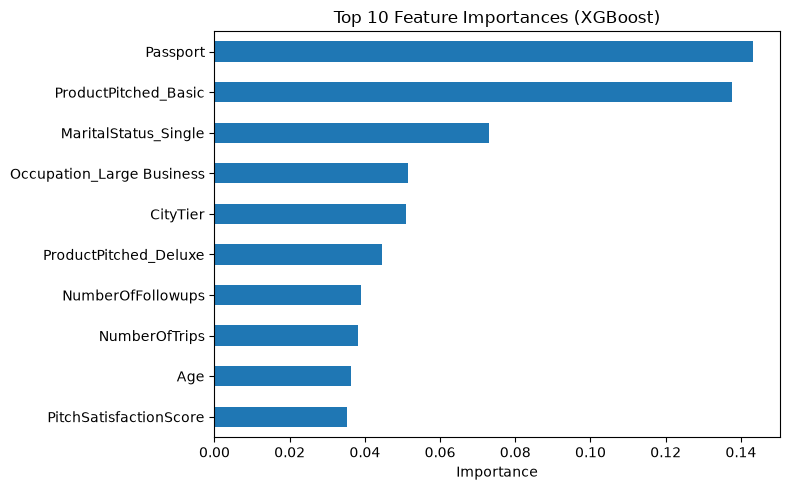

In [13]:
best_pipeline = joblib.load("tourism_project/deployment/model.joblib")
xgb_model = best_pipeline.named_steps["xgbclassifier"]
feature_names = best_pipeline.named_steps["columntransformer"].get_feature_names_out()
feature_names = [f.split("__", 1)[-1] for f in feature_names]

importances = pd.Series(xgb_model.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=True).tail(10)

plt.figure(figsize=(8, 5))
importances.plot(kind="barh")
plt.title("Top 10 Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


**Observation:** Passport ownership is by far the strongest predictor, followed by whether the Basic or Deluxe package was pitched, marital status (Single), being in Large Business occupation, city tier, and the number of sales follow-ups and trips. Customers who already travel internationally (hold a passport) and are pitched entry-level or premium packages appear most receptive — a useful signal for who to prioritize contacting.

# Deployment

In [14]:
os.makedirs("tourism_project/deployment", exist_ok=True)


## Streamlit App

`app.py` loads the trained model committed to `tourism_project/deployment/` by the pipeline, collects the user inputs into a dataframe, and displays the prediction. Streamlit Community Cloud runs this file directly from the repo.

In [15]:
%%writefile tourism_project/deployment/app.py
"""
Streamlit app for the "Visit with Us" Wellness Tourism Package predictor.

Loads the model trained and committed by the MLOps pipeline
(tourism_project/deployment/model.joblib) and predicts whether a customer
is likely to purchase the Wellness Tourism Package.
"""

import os

import joblib
import pandas as pd
import streamlit as st

MODEL_PATH = os.path.join(os.path.dirname(__file__), "model.joblib")

st.set_page_config(page_title="Wellness Tourism Package Predictor", page_icon="🧳")


@st.cache_resource
def load_model():
    return joblib.load(MODEL_PATH)


model = load_model()

st.title("🧳 Wellness Tourism Package Predictor")
st.write(
    "Predict whether a customer is likely to purchase the new **Wellness "
    "Tourism Package**, based on their profile and sales-pitch interaction "
    "details."
)

st.header("Customer Details")
col1, col2 = st.columns(2)

with col1:
    age = st.number_input("Age", min_value=18, max_value=100, value=35)
    type_of_contact = st.selectbox(
        "Type of Contact", ["Self Enquiry", "Company Invited"]
    )
    city_tier = st.selectbox("City Tier", [1, 2, 3])
    occupation = st.selectbox(
        "Occupation", ["Salaried", "Free Lancer", "Small Business", "Large Business"]
    )
    gender = st.selectbox("Gender", ["Male", "Female"])
    marital_status = st.selectbox(
        "Marital Status", ["Single", "Married", "Divorced"]
    )
    designation = st.selectbox(
        "Designation", ["Executive", "Manager", "Senior Manager", "AVP", "VP"]
    )
    monthly_income = st.number_input(
        "Monthly Income", min_value=0, value=20000, step=500
    )

with col2:
    number_of_persons_visiting = st.number_input(
        "Number of Persons Visiting", min_value=1, max_value=10, value=2
    )
    number_of_children_visiting = st.number_input(
        "Number of Children Visiting (below age 5)", min_value=0, max_value=10, value=0
    )
    preferred_property_star = st.selectbox("Preferred Property Star", [3.0, 4.0, 5.0])
    number_of_trips = st.number_input(
        "Average Number of Trips per Year", min_value=0, max_value=20, value=2
    )
    passport = st.selectbox("Holds Passport?", ["Yes", "No"])
    own_car = st.selectbox("Owns a Car?", ["Yes", "No"])

st.header("Sales Interaction Details")
col3, col4 = st.columns(2)

with col3:
    product_pitched = st.selectbox(
        "Product Pitched", ["Basic", "Standard", "Deluxe", "Super Deluxe", "King"]
    )
    duration_of_pitch = st.number_input(
        "Duration of Pitch (minutes)", min_value=1, max_value=60, value=15
    )

with col4:
    number_of_followups = st.number_input(
        "Number of Follow-ups", min_value=0, max_value=10, value=3
    )
    pitch_satisfaction_score = st.selectbox("Pitch Satisfaction Score", [1, 2, 3, 4, 5])

if st.button("Predict"):
    input_df = pd.DataFrame(
        [
            {
                "Age": age,
                "TypeofContact": type_of_contact,
                "CityTier": city_tier,
                "DurationOfPitch": duration_of_pitch,
                "Occupation": occupation,
                "Gender": gender,
                "NumberOfPersonVisiting": number_of_persons_visiting,
                "NumberOfFollowups": number_of_followups,
                "ProductPitched": product_pitched,
                "PreferredPropertyStar": preferred_property_star,
                "MaritalStatus": marital_status,
                "NumberOfTrips": number_of_trips,
                "Passport": 1 if passport == "Yes" else 0,
                "PitchSatisfactionScore": pitch_satisfaction_score,
                "OwnCar": 1 if own_car == "Yes" else 0,
                "NumberOfChildrenVisiting": number_of_children_visiting,
                "Designation": designation,
                "MonthlyIncome": monthly_income,
            }
        ]
    )

    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0][1]

    st.subheader("Prediction Result")
    if prediction == 1:
        st.success(
            f"✅ This customer is **likely to purchase** the Wellness Tourism "
            f"Package (probability: {probability:.1%})."
        )
    else:
        st.warning(
            f"❌ This customer is **unlikely to purchase** the Wellness Tourism "
            f"Package (probability: {probability:.1%})."
        )

    st.dataframe(input_df)


Overwriting tourism_project/deployment/app.py


## App Dependencies

In [16]:
%%writefile tourism_project/deployment/requirements.txt
streamlit==1.60.0
pandas==2.3.3
scikit-learn==1.9.0
xgboost==3.2.0
joblib==1.5.3


Overwriting tourism_project/deployment/requirements.txt


# MLOps Pipeline with Github Actions Workflow

The workflow below registers the dataset, prepares train/test splits, tunes and trains the model with MLflow tracking, and commits the best model back to the repository — automatically, on every push to `main`.

In [17]:
os.makedirs(".github/workflows", exist_ok=True)


In [18]:
%%writefile .github/workflows/pipeline.yml
name: Tourism Project Pipeline

on:
  push:
    branches:
      - main  # Automatically triggers on push to the main branch
  workflow_dispatch:  # lets you click "Run workflow" in the Actions tab

permissions:
  contents: write

jobs:

  register-dataset:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - uses: actions/setup-python@v5
        with:
          python-version: "3.11"
      - name: Install Dependencies
        run: pip install -r requirements.txt
      - name: Register Dataset
        run: python tourism_project/model_building/data_register.py
      - name: Upload Registered Dataset
        uses: actions/upload-artifact@v4
        with:
          name: registered-data
          path: tourism_project/data/tourism.csv

  data-prep:
    needs: register-dataset
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - uses: actions/setup-python@v5
        with:
          python-version: "3.11"
      - name: Install Dependencies
        run: pip install -r requirements.txt
      - name: Run Data Preparation
        run: python tourism_project/model_building/prep.py
      - name: Upload Train Test Splits
        uses: actions/upload-artifact@v4
        with:
          name: data-splits
          path: |
            Xtrain.csv
            Xtest.csv
            ytrain.csv
            ytest.csv

  model-traning:
    needs: data-prep
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - uses: actions/setup-python@v5
        with:
          python-version: "3.11"
      - name: Install Dependencies
        run: pip install -r requirements.txt
      - name: Download Train Test Splits
        uses: actions/download-artifact@v4
        with:
          name: data-splits
      - name: Start MLflow Server
        run: |
          nohup mlflow ui --host 0.0.0.0 --port 5000 &  # Run MLflow UI in the background
          sleep 5  # Wait for a moment to let the server starts
      - name: Model Building
        run: python tourism_project/model_building/train.py
      - name: Commit Trained Model
        run: |
          git config user.name "github-actions[bot]"
          git config user.email "github-actions[bot]@users.noreply.github.com"
          git add tourism_project/deployment/model.joblib
          git commit -m "Add trained model [skip ci]" || echo "No changes to commit"
          git push


Overwriting .github/workflows/pipeline.yml


## Requirements file for the Github Actions Workflow

In [19]:
%%writefile requirements.txt
pandas==2.3.3
scikit-learn==1.9.0
xgboost==3.2.0
mlflow==3.0.1
joblib==1.5.3


Overwriting requirements.txt


## Version Control & Push to GitHub

All the files above (the `tourism_project/` folder, `.github/workflows/`, and `requirements.txt`) were committed with `git` and pushed directly to `main` on **[https://github.com/craghav12/tourism-package-prediction](https://github.com/craghav12/tourism-package-prediction)`** using the GitHub CLI (`gh`), which was already authenticated on this machine — no PAT or Colab secret needed. The cells below are read-only checks that confirm the push and the automated pipeline run succeeded.

In [20]:
!git -c color.ui=false remote -v
!echo "---"
!git -c color.ui=false log --oneline -8


origin	https://github.com/craghav12/tourism-package-prediction.git (fetch)
origin	https://github.com/craghav12/tourism-package-prediction.git (push)


---


bae8ba7 (HEAD -> main, origin/main) Add executed submission notebook and HTML export
0374c1f Add trained model [skip ci]
2ea6a64 Initial commit: tourism package prediction MLOps pipeline


In [21]:
import os
os.environ["NO_COLOR"] = "1"
!gh run list --repo craghav12/tourism-package-prediction --limit 5 | cat


completed	success	Added Dev Container Folder	Tourism Project Pipeline	main	push	30609856627	3m2s	2026-07-31T06:30:32Z
completed	success	Add executed submission notebook and HTML export	Tourism Project Pipeline	main	push	30609174584	2m50s	2026-07-31T06:16:47Z
completed	success	Initial commit: tourism package prediction MLOps pipeline	Tourism Project Pipeline	main	push	30608640734	3m15s	2026-07-31T06:05:49Z


# Deploy the App on Streamlit Community Cloud

After the pipeline finishes, the trained model is committed to `tourism_project/deployment/`. Deploy the app as follows:

1. Go to **https://share.streamlit.io** and sign in with the GitHub account that owns the repository (`craghav12`).
2. Click **Create app**.
3. Set:
   - **Repository:** `craghav12/tourism-package-prediction`
   - **Branch:** `main`
   - **Main file path:** `tourism_project/deployment/app.py`
4. Open **Advanced settings** and set **Python version** to **3.11** so the saved model loads with the same library versions used during training.
5. Click **Deploy**.

Streamlit installs the packages from `tourism_project/deployment/requirements.txt` and launches the app at a public `...streamlit.app` URL. Add this link and a screenshot to the Output Evaluation section below.


# Output Evaluation

- **GitHub:** [https://github.com/craghav12/tourism-package-prediction](https://github.com/craghav12/tourism-package-prediction) — repository with the folder structure shown above and a green, executed `Tourism Project Pipeline` workflow run. _(Add a screenshot of the repo folder structure and the executed Actions run here.)_

- **Streamlit Community Cloud:** https://tourism-package-prediction-craghav12.streamlit.app/ _(Add a screenshot of the deployed Streamlit app here.)_

# Conclusion & Key Insights

**Data:**
- The raw dataset had 4,128 rows; cleaning removed 117 exact duplicate rows and two non-predictive identifier columns, and normalized inconsistent category labels (`"Fe Male"` → `"Female"`, `"Unmarried"` → `"Single"`).
- The target is imbalanced — only ~19% of customers purchased the package — so accuracy alone is a misleading metric; ROC-AUC and recall on the minority class matter more for this business problem.

**Model:**
- A tuned XGBoost classifier achieves a test ROC-AUC of **~0.93** and accuracy of **~90%**, with precision of **~0.86** and recall of **~0.59** on customers who actually purchase the package.
- The moderate recall means the model misses some genuine buyers — acceptable for a marketing-targeting use case where the cost of a missed campaign contact is lower than the cost of contacting everyone, but worth revisiting (e.g. by adjusting the classification threshold or class weighting) if the business wants to prioritize catching more buyers over pitch efficiency.
- Passport ownership is the single strongest predictor, followed by which package tier was pitched, marital status, occupation, and city tier — pointing to concrete targeting levers (e.g. prioritizing passport-holders and tuning which package tier is pitched to whom) beyond just the model itself.

**MLOps Pipeline:**
- The GitHub Actions workflow fully automates dataset registration, data preparation, and model tuning/training/logging on every push to `main`, and commits the retrained model straight back into the repository the Streamlit app serves from — closing the loop from code change to deployed model with no manual steps.
- MLflow experiment tracking logs every hyperparameter combination tried during the grid search, so the tuning history is fully auditable, not just the final chosen model.


<font size=6 color="navyblue">Power Ahead!</font>
___